# Notebook 05 — Full Fine-Tuning (FFT)

Full Fine-Tuning of `Qwen2.5-1.5B-Instruct` — all parameters updated.

> **Why 1.5B instead of 3B?** RTX 5070 Laptop has 8 GB VRAM.  
> FFT on 3B requires ~18 GB (weights + optimizer states). The 1.5B model  
> uses ~3 GB weights + ~4 GB optimizer states = fits in 8 GB.  
> This still gives a meaningful LoRA-3B vs FFT-1.5B comparison.

**Trainable params**: 1.54B (100%)  
**Expected VRAM**: ~7 GB  
**Expected time**: ~3-4 hours (3 epochs)

In [1]:
import sys
import gc
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..').resolve()))
from src.model_utils import load_model_and_tokenizer, print_model_info
from src.data_utils import load_jsonl_as_hf_dataset
from src.training_utils import build_fft_training_args

from trl import SFTTrainer

ROOT          = Path('..').resolve()
PROCESSED_DIR = ROOT / 'data' / 'processed'
HF_CACHE      = ROOT / 'data' / 'raw' / 'huggingface_cache'
OUTPUT_DIR    = ROOT / 'outputs' / 'fft'
FIG_DIR       = ROOT / 'outputs' / 'results' / 'figures'

# 1.5B for FFT on 8 GB VRAM — 3B would require ~18 GB
MODEL_ID = 'Qwen/Qwen2.5-1.5B-Instruct'

print('Setup complete.')
print(f'GPU:  {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Setup complete.
GPU:  NVIDIA RTX PRO 5000 Blackwell
VRAM: 50.8 GB


## 1. Load Datasets

In [2]:
train_dataset = load_jsonl_as_hf_dataset(PROCESSED_DIR / 'train.jsonl')
val_dataset   = load_jsonl_as_hf_dataset(PROCESSED_DIR / 'val.jsonl')
print('Train:', train_dataset)
print('Val:  ', val_dataset)

Train: Dataset({
    features: ['messages'],
    num_rows: 40084
})
Val:   Dataset({
    features: ['messages'],
    num_rows: 2234
})


## 2. Load Model (BF16, All Parameters Trainable)

In [3]:
# 1.5B in BF16 = ~3 GB weights — leaves room for optimizer states on 8 GB
model, tokenizer = load_model_and_tokenizer(
    MODEL_ID,
    quantization=None,           # BF16 full precision
    attn_implementation='eager',
)

print_model_info(model)  # Should show 100% trainable

if torch.cuda.is_available():
    print(f'VRAM after model load: {torch.cuda.memory_allocated(0)/1e9:.2f} GB')
    print('Note: optimizer states add ~2x model size during training')

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Total parameters:     1,543,714,304
Trainable parameters: 1,543,714,304  (100.00%)
VRAM after model load: 3.09 GB
Note: optimizer states add ~2x model size during training


## 3. Training Configuration (8 GB tuned)

In [4]:
training_args = build_fft_training_args(
    output_dir=str(OUTPUT_DIR / 'checkpoints'),
    # 8 GB VRAM overrides
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,  # effective batch = 16
    max_length=256,
    optim='paged_adamw_32bit',       # essential for FFT on 8 GB
)

print('Key FFT training arguments:')
print(f'  per_device_train_batch_size:  {training_args.per_device_train_batch_size}')
print(f'  gradient_accumulation_steps:  {training_args.gradient_accumulation_steps}')
print(f'  effective batch size:         {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}')
print(f'  learning_rate:                {training_args.learning_rate}  (10x lower than LoRA)')
print(f'  optimizer:                    {training_args.optim}')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Key FFT training arguments:
  per_device_train_batch_size:  1
  gradient_accumulation_steps:  16
  effective batch size:         16
  learning_rate:                2e-05  (10x lower than LoRA)
  optimizer:                    OptimizerNames.PAGED_ADAMW


## 4. Train

In [5]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    # No peft_config: full fine-tuning
)

print('Starting FFT training (Qwen2.5-1.5B-Instruct) ...')
train_result = trainer.train()

print(f'\nTraining complete.')
print(f'  Train loss: {train_result.training_loss:.4f}')
print(f'  Steps:      {train_result.global_step}')

Tokenizing train dataset:   0%|          | 0/40084 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/2234 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting FFT training (Qwen2.5-1.5B-Instruct) ...


Step,Training Loss,Validation Loss
200,1.138580,1.079674
400,1.096368,1.060534
600,1.063256,1.051429
800,1.063109,1.048096
1000,1.052445,1.049211
1200,1.046645,1.048989
1254,1.036090,1.048826


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].



Training complete.
  Train loss: 1.1240
  Steps:      1254


## 5. Save Full Fine-Tuned Model

In [6]:
model_path = str(OUTPUT_DIR / 'final_model')
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)
print(f'FFT model saved to: {model_path}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

FFT model saved to: /home/prasingh/data/AdvNLP/outputs/fft/final_model


## 6. Training Loss Curve

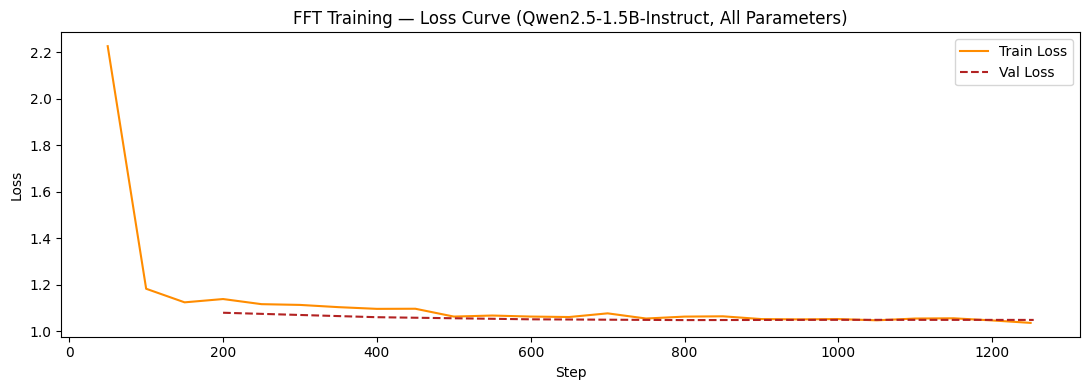

In [7]:
log_df = pd.DataFrame(trainer.state.log_history)
train_loss = log_df[log_df['loss'].notna()][['step', 'loss']]
eval_loss  = log_df[log_df['eval_loss'].notna()][['step', 'eval_loss']]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train_loss['step'], train_loss['loss'], label='Train Loss', color='darkorange')
ax.plot(eval_loss['step'], eval_loss['eval_loss'], label='Val Loss', color='firebrick', linestyle='--')
ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.set_title('FFT Training — Loss Curve (Qwen2.5-1.5B-Instruct, All Parameters)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fft_loss_curve.png', dpi=150)
plt.show()

In [8]:
del model, trainer
gc.collect()
torch.cuda.empty_cache()
print('Memory freed.')

Memory freed.
